Pre processing for cross data analysis on CICDS2018 dataset according to the pre existing CICDS2017 pipeline

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

In [52]:
# 14 - Brute Force
# 16 - DoS
# 21 - DdoS
# 02 - Bot

In [54]:
paths = ["../raw/CICDS2018/"+ x for x in os.listdir("../raw/CICDS2018") if x.endswith('.csv')]

In [55]:

print(os.getcwd())
for p in paths:
    print(p, "->", os.path.exists(p))


d:\Projects\Network_Anomaly_Detection_CICIDS2017\cross_dataset_val
../raw/CICDS2018/02-03-2018.csv -> True
../raw/CICDS2018/02-14-2018.csv -> True
../raw/CICDS2018/02-16-2018.csv -> True
../raw/CICDS2018/02-21-2018.csv -> True


In [56]:
paths

['../raw/CICDS2018/02-03-2018.csv',
 '../raw/CICDS2018/02-14-2018.csv',
 '../raw/CICDS2018/02-16-2018.csv',
 '../raw/CICDS2018/02-21-2018.csv']

In [57]:
columns_list = [pd.read_csv(p,nrows=0).columns.to_list() for p in paths]
all_same = all(cols == columns_list[0] for cols in columns_list)
print("All datasets have matching columns:", all_same)

All datasets have matching columns: True


In [59]:
dfs=[pd.read_csv(p) for p in paths]

cv_df = pd.concat(dfs,axis=0,ignore_index=True) 


print(len(cv_df))

#total should be 2830743 rows

C:\Users\mohak\AppData\Local\Temp\ipykernel_23480\2486649499.py:1: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs=[pd.read_csv(p) for p in paths]


4194300


In [60]:
print(cv_df['Label'].value_counts())

Label
Benign                      2237615
DDOS attack-HOIC             686012
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
DoS attacks-SlowHTTPTest     139890
DDOS attack-LOIC-UDP           1730
Label                             1
Name: count, dtype: int64


In [62]:
attack_type_test = {
    'Benign': 'BENIGN',
    'DDOS attack-HOIC': 'DDoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Hulk ': 'DoS',
    'FTP-BruteForce': 'Brute Force',
    'SSH-BruteForce': 'Brute Force',
    'Bot': 'Bot',
}


cv_df['Label'] = cv_df['Label'].map(attack_type_test)

In [63]:
print(cv_df['Label'].value_counts())

Label
BENIGN         2237615
DDoS            687742
Bot             286191
Brute Force     193360
DoS             139890
Name: count, dtype: int64


In [72]:

test_unique_attacks = cv_df['Label'].value_counts().tolist()
test_unique_attacks_names = cv_df['Label'].value_counts().index

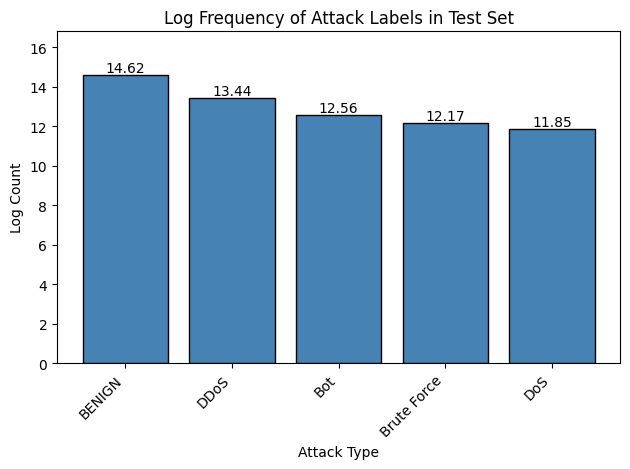

In [73]:
bars = plt.bar(
    test_unique_attacks_names,
    np.log(test_unique_attacks),
    color="steelblue",
    edgecolor="black"
)

for bar, value in zip(bars, np.log(test_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Attack Labels in Test Set")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
ymax = max(np.log(test_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()

Removing Duplicates

In [74]:

dups_test = cv_df[cv_df.duplicated()]
print(f"Number of Test Duplicates: {len(dups_test)}")

Number of Test Duplicates: 394491


In [75]:
total_test = cv_df.shape[0]
unique_count_test = total_test - len(dups_test)
labels = ["Unique Rows", "Duplicate Rows"]
values_test = [unique_count_test, len(dups_test)]

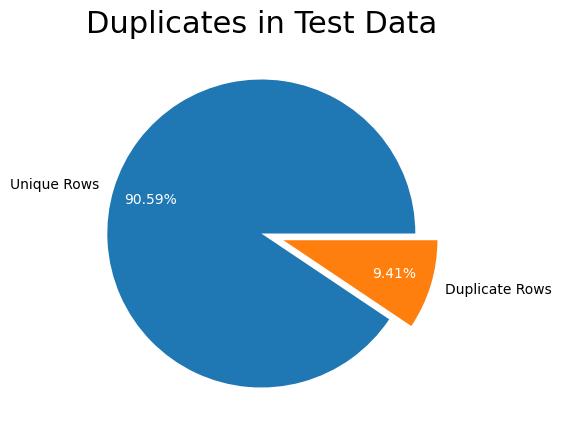

In [76]:
plt.figure(figsize=(5, 5))

plt.pie(
    values_test,
    labels=labels,
    autopct="%1.2f%%",
    explode=[0, 0.15],  # push duplicates outward for emphasis
    pctdistance=0.75,
)
# fix autopct text color (white)
for text in plt.gca().texts:
    if "%" in text.get_text():           # identify only the percentage texts
        text.set_color("white")
plt.title("Duplicates in Test Data", fontsize=22)
plt.show()

In [77]:

print(f"Test shape before dropping Duplicates: {cv_df.shape}")
test_size = len(cv_df)
cv_df.drop_duplicates(inplace=True)
test_size_after = len(cv_df)
print(f"Test shape after dropping Duplicates: {cv_df.shape}")

Test shape before dropping Duplicates: (4194300, 80)
Test shape after dropping Duplicates: (3799809, 80)


In [78]:
cv_df = cv_df.reset_index(drop=True)

In [85]:
cv_df['Label'].value_counts(dropna=False)

Label
BENIGN         2234658
DDoS            670191
NaN             552206
Bot             282310
Brute Force      39352
DoS              21092
Name: count, dtype: int64

Handling missing and infinity

In [81]:
missing_val_test = cv_df.isna().sum()
print("Test:")
print(missing_val_test.loc[missing_val_test > 0])

Test:
Flow Byts/s      4835
Label          552206
dtype: int64


In [83]:
numeric_cols = cv_df.select_dtypes(include = np.number).columns
inf_count = np.isinf(cv_df[numeric_cols]).sum()
print("Test Inf Values")
print(inf_count[inf_count > 0])

Test Inf Values
Series([], dtype: float64)


In [ ]:
missing_test = cv_df.isna().sum()
print("Test:")
print(missing_test.loc[missing_test > 0])

Test:
Flow Byts/s      4835
Label          552206
dtype: int64


In [89]:
cv_df = cv_df.dropna(subset=['Label'])

In [90]:
missing_test = cv_df.isna().sum()
print("Test:")
print(missing_test.loc[missing_test > 0])

Test:
Flow Byts/s    4835
dtype: int64


In [91]:
mis_per = (missing_test / len(cv_df)) * 100
mis_table = pd.concat([missing_test, mis_per.round(2)], axis = 1)
print("\n\nTest:")
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})
print(mis_table.loc[mis_per > 0])



Test:
             Missing Values  Percentage of Total Values
Flow Byts/s            4835                        0.15


In [93]:
median_flow_bytes_test = cv_df['Flow Byts/s'].median()
print('Test Median of Flow Bytes/s: ', median_flow_bytes_test)

Test Median of Flow Bytes/s:  322.78528785000003


In [94]:
cv_df['Flow Byts/s'].fillna(median_flow_bytes_test, inplace = True)

C:\Users\mohak\AppData\Local\Temp\ipykernel_23480\1389370008.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cv_df['Flow Byts/s'].fillna(median_flow_bytes_test, inplace = True)
C:\Users\mohak\AppData\Local\Temp\ipykernel_23480\1389370008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cv_df['Flow Byts/s'].fillna(median_flow_bytes_test,

In [95]:
print('Number of \'Flow Bytes/s\' missing values:', cv_df['Flow Byts/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0


In [97]:
cv_df['Label'].value_counts(dropna=False)

Label
BENIGN         2234658
DDoS            670191
Bot             282310
Brute Force      39352
DoS              21092
Name: count, dtype: int64

In [98]:
cv_df.shape

(3247603, 80)

In [100]:
rename_map = {
    "Dst Port": "Destination Port",
    "Tot Fwd Pkts": "Total Fwd Packets",
    "Tot Bwd Pkts": "Total Backward Packets",
    "TotLen Fwd Pkts": "Total Length of Fwd Packets",
    "TotLen Bwd Pkts": "Total Length of Bwd Packets",
    "Fwd Pkt Len Max": "Fwd Packet Length Max",
    "Fwd Pkt Len Min": "Fwd Packet Length Min",
    "Fwd Pkt Len Mean": "Fwd Packet Length Mean",
    "Fwd Pkt Len Std": "Fwd Packet Length Std",
    "Bwd Pkt Len Max": "Bwd Packet Length Max",
    "Bwd Pkt Len Min": "Bwd Packet Length Min",
    "Bwd Pkt Len Mean": "Bwd Packet Length Mean",
    "Bwd Pkt Len Std": "Bwd Packet Length Std",
    "Flow Byts/s": "Flow Bytes/s",
    "Flow Pkts/s": "Flow Packets/s",
    "Fwd IAT Tot": "Fwd IAT Total",
    "Bwd IAT Tot": "Bwd IAT Total",
    "Pkt Len Min": "Min Packet Length",
    "Pkt Len Max": "Max Packet Length",
    "Pkt Len Mean": "Packet Length Mean",
    "Pkt Len Std": "Packet Length Std",
    "Pkt Len Var": "Packet Length Variance",
    "FIN Flag Cnt": "FIN Flag Count",
    "SYN Flag Cnt": "SYN Flag Count",
    "RST Flag Cnt": "RST Flag Count",
    "PSH Flag Cnt": "PSH Flag Count",
    "ACK Flag Cnt": "ACK Flag Count",
    "URG Flag Cnt": "URG Flag Count",
    "ECE Flag Cnt": "ECE Flag Count",
    "Pkt Size Avg": "Average Packet Size",
    "Fwd Seg Size Avg": "Avg Fwd Segment Size",
    "Bwd Seg Size Avg": "Avg Bwd Segment Size",
    "Subflow Fwd Pkts": "Subflow Fwd Packets",
    "Subflow Fwd Byts": "Subflow Fwd Bytes",
    "Subflow Bwd Pkts": "Subflow Bwd Packets",
    "Subflow Bwd Byts": "Subflow Bwd Bytes",
    "Init Fwd Win Byts": "Init_Win_bytes_forward",
    "Init Bwd Win Byts": "Init_Win_bytes_backward",
    "Fwd Act Data Pkts": "act_data_pkt_fwd",
    "Fwd Seg Size Min": "min_seg_size_forward"
}

In [101]:
cv_df = cv_df.rename(columns=rename_map)

In [103]:
cv_df.drop(columns=["Protocol", "Timestamp"], errors="ignore", inplace=True)

In [107]:
cv_df.rename(columns={'Label':'Attack'},inplace=True)

In [108]:
cv_df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Pkts/s', 'Bwd Pkts/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Cou

In [109]:
non_numeric = cv_df.select_dtypes(exclude=['number']).columns
print(non_numeric)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Pkts/s', 'Bwd Pkts/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Cou

In [110]:
label = cv_df["Attack"]
features = cv_df.drop(columns=["Attack"])

In [111]:
features = features.apply(pd.to_numeric, errors="coerce")

In [113]:
cv_df = features.copy()
cv_df["Attack"] = label

In [114]:
cv_df.to_parquet('test.parquet')

In [2]:
test_df = pd.read_parquet('test.parquet')

In [3]:
import joblib
encoder = joblib.load("../scalers/label_enoder.joblib")
test_df['Attack']= encoder.transform(test_df['Attack'])
test_df['Attack'].value_counts()


Attack
0    2234658
3     670191
1     282310
2      39352
4      21092
Name: count, dtype: int64

In [4]:
encoded_values = test_df['Attack'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {encoder.inverse_transform([val])[0]}")

0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS


In [5]:
for col in test_df.columns:
    col_type = test_df[col].dtype
    if col_type != object:
        c_min = test_df[col].min()
        c_max = test_df[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            test_df[col] = test_df[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            test_df[col] = test_df[col].astype(np.int32)

In [6]:
test_df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Pkts/s', 'Bwd Pkts/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Cou

In [7]:
rename_map = {
    "Fwd Header Len": "Fwd Header Length",
    "Bwd Header Len": "Bwd Header Length",
    "Fwd Pkts/s": "Fwd Packets/s",
    "Bwd Pkts/s": "Bwd Packets/s",
    "Fwd Byts/b Avg": "Fwd Avg Bytes/Bulk",
    "Fwd Pkts/b Avg": "Fwd Avg Packets/Bulk",
    "Fwd Blk Rate Avg": "Fwd Avg Bulk Rate",
    "Bwd Byts/b Avg": "Bwd Avg Bytes/Bulk",
    "Bwd Pkts/b Avg": "Bwd Avg Packets/Bulk",
    "Bwd Blk Rate Avg": "Bwd Avg Bulk Rate"
}

test_df.rename(columns=rename_map, inplace=True)

In [8]:
old_df_cols = ['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
       'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
       'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk',
       'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk',
       'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
       'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward',
       'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',
       'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean',
       'Idle Std', 'Idle Max', 'Idle Min', 'Attack']

print(list(test_df.columns) == old_df_cols)

True


In [9]:
dropped_cols = ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
test_df.drop(columns= dropped_cols, errors="ignore", inplace=True)




In [10]:
test_df.shape

(3247603, 70)

In [11]:
MAX_SAMPLES = 5000
class_counts_test = test_df['Attack'].value_counts()


selected_classes_test = class_counts_test[class_counts_test >= 400]
class_names_test = selected_classes_test.index


selected_test = test_df[test_df['Attack'].isin(class_names_test)] 

dfs_test = []

for name in class_names_test:
    df_test = selected_test[selected_test['Attack'] == name]

    if len(df_test) > MAX_SAMPLES:
        df_test = df_test.sample(n = MAX_SAMPLES, random_state = 42, replace = False)

    dfs_test.append(df_test)


test_final = pd.concat(dfs_test, ignore_index = True)



print(test_final['Attack'].value_counts())

Attack
0    5000
3    5000
1    5000
2    5000
4    5000
Name: count, dtype: int64


In [12]:
numeric_cols = test_final.select_dtypes(include = np.number).columns
inf_count = np.isinf(test_final[numeric_cols]).sum()
print("Test Inf Values")
print(inf_count[inf_count > 0])

Test Inf Values
Flow Bytes/s       7
Flow Packets/s    23
dtype: int64


In [13]:
print(f'Initial missing values Test: {test_final.isna().sum().sum()}')

test_final.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values for Train: {test_final.isna().sum().sum()}')

Initial missing values Test: 0
Missing values after processing infinite values for Train: 30


In [15]:
missing_test = test_final.isna().sum()
print("Test:")
print(missing_test.loc[missing_test > 0])

Test:
Flow Bytes/s       7
Flow Packets/s    23
dtype: int64


In [17]:
median_flow_bytes_test = test_final['Flow Bytes/s'].median()
median_flow_packets_test = test_final['Flow Packets/s'].median()

print('Test Median of Flow Bytes/s: ', median_flow_bytes_test)
print('Test Median of Flow Packets/s: ', median_flow_packets_test)

Test Median of Flow Bytes/s:  0.0
Test Median of Flow Packets/s:  4065.04065


In [18]:
test_final['Flow Bytes/s'].fillna(median_flow_bytes_test, inplace = True)
test_final['Flow Packets/s'].fillna(median_flow_packets_test, inplace = True)

C:\Users\mohak\AppData\Local\Temp\ipykernel_28812\2757820089.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_final['Flow Bytes/s'].fillna(median_flow_bytes_test, inplace = True)
C:\Users\mohak\AppData\Local\Temp\ipykernel_28812\2757820089.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [19]:
print('Number of \'Flow Bytes/s\' missing values:', test_final['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', test_final['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


In [21]:
test_final['Attack'].value_counts()

Attack
0    5000
3    5000
1    5000
2    5000
4    5000
Name: count, dtype: int64

In [22]:
test_final.shape

(25000, 70)

In [23]:
test_final.to_parquet('unscaled_cicds2018.parquet')